# Free spectrum tutorial - Parallelized with Dask

This notebook demonstrates how to run free spectrum analysis on multiple AGN in parallel using Dask.

**Key concepts:**
- Use `@delayed` decorator to create parallel tasks for each AGN
- Store posterior samples as nested columns using `join_nested`
- Works with both simulations (`NestedFrame`) and LSDB catalogs

In [1]:
%load_ext autoreload
%autoreload 2
import logging
from pathlib import Path

logging.basicConfig(level="ERROR")

import arviz as az
import jax
import numpy as np
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import pandas as pd
from dask import delayed, compute

from angst import analysis, dataset, simulation, utils
import nested_pandas as npd
import lsdb.nested as nd
from dask.distributed import Client

In [2]:
client = Client(n_workers=5, threads_per_worker=1, memory_limit="4GB")
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-m7vb9wsd', purging
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42135
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44513'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46861'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41115'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33451'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37923'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42165 name: 1
INFO:distributed.scheduler:Starting worker compute strea

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 5,Total memory: 18.63 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42135,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46349,Total threads: 1
Dashboard: http://127.0.0.1:33145/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:44513,


INFO:distributed.core:Event loop was unresponsive in Nanny for 2498.74s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 2498.74s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 2498.74s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 2498.75s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 2498.75s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This ca

## Creating a simulated dataset
To be completely self-contained, we'll make our own DRW dataset.

In [3]:
# Set parameters for simulation
rng_key = jax.random.key(0)
tspan, cadence, season = 365 * 10, 7, None
timestamps = utils.make_timestamps(tspan, cadence, rng_key)
mask = utils.make_season_mask(timestamps, season)
timestamps_season = timestamps[mask]
amplitude = dist.Uniform(1e-3, 3)
timescale = dist.Normal(180, 60)
cadence = cadence
snr = 20
mean_mag = 16
seed_num = 0
out_file = Path.cwd() / "drw-simulation.pq"

agn_id = 3

# Create simulation object
drw = simulation.DampedRandomWalkSim(
    amplitude, timescale, cadence, snr, mean_mag, seed_num, season, tspan
)

# Run the simulation
drw.simulate(out_file, rng_key, 5)

# Read in the simulation and check some data
dset = dataset.DataSet(out_file, name="Example Simulation")
dset.get_cols_for_id(agn_id, "lc.mjd", "lc.mag", "lc.mag_error", bands="r")

lc
3  [{mjd: 0.995522, mag: 16.425891, mag_error: 1....

## It's just a (Nested) Pandas DataFrame
We can do typical operations, like plotting

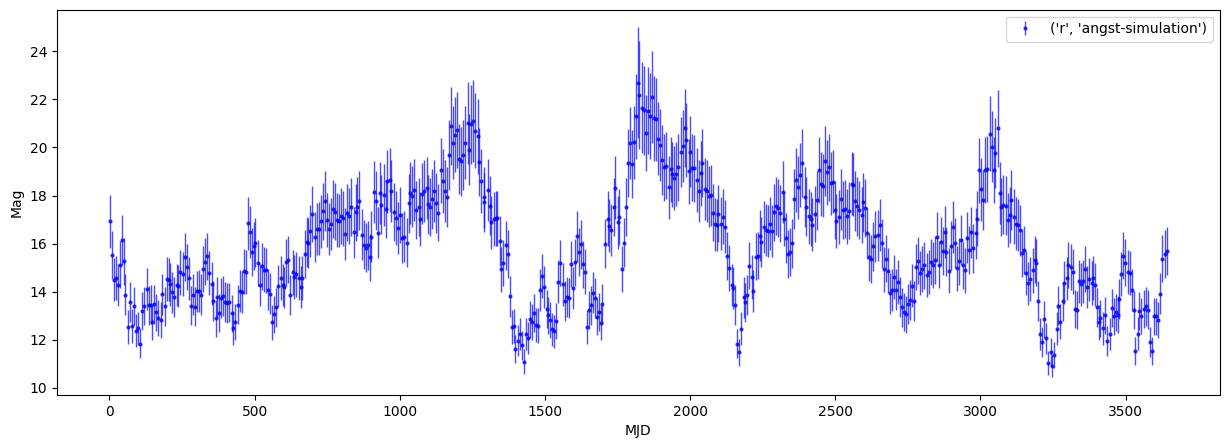

In [4]:
colors = ["blue", "green", "red", "orange"]
fig, ax = plt.subplots(figsize=(15, 5))
for i, (name, group) in enumerate(dset.df.iloc[0]["lc"].groupby(["band", "survey"])):
    ax.errorbar(
        x=group.mjd,
        y=group.mag,
        yerr=group.mag_error,
        marker="o",
        linestyle="",
        ms=2,
        elinewidth=1,
        label=name,
        alpha=0.7,
        color=colors[i],
    )
ax.set_xlabel("MJD")
ax.set_ylabel("Mag")
_ = ax.legend()

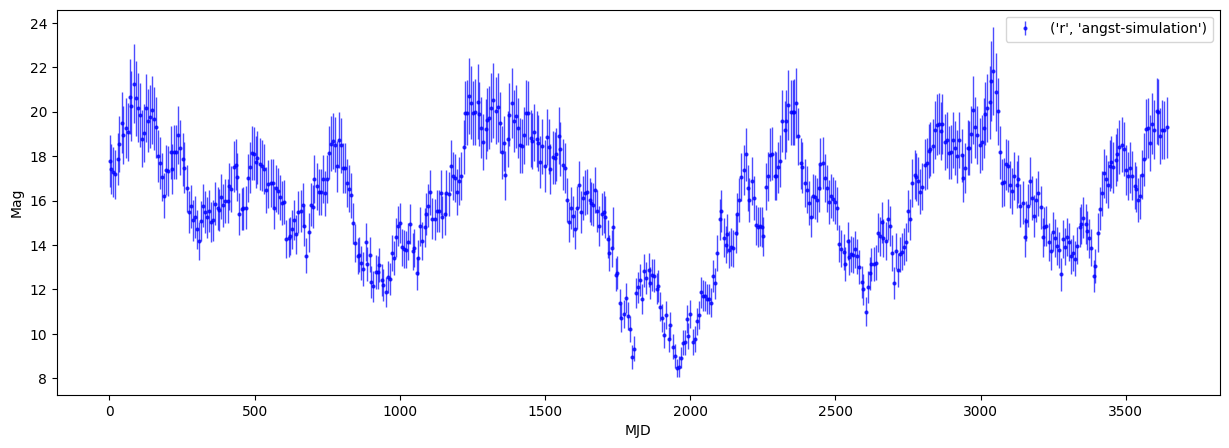

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
for i, (name, group) in enumerate(dset.df.iloc[4]["lc"].groupby(["band", "survey"])):
    ax.errorbar(
        x=group.mjd,
        y=group.mag,
        yerr=group.mag_error,
        marker="o",
        linestyle="",
        ms=2,
        elinewidth=1,
        label=name,
        alpha=0.7,
        color=colors[i],
    )
ax.set_xlabel("MJD")
ax.set_ylabel("Mag")
_ = ax.legend()

The input parameters are saved in the dataframe as a nested dataframe `input_parameters`

In [6]:
dset.df.head()

id          ra        dec  \
0   0  234.692012  45.102399   
1   1  145.523735  -66.04436   
2   2  278.718174  29.627104   
3   3   15.412092 -46.341703   
4   4  203.802929  60.215188   

                                                  lc  \
0  [{mjd: 1.400884, mag: 16.925767, mag_error: 1....   
1  [{mjd: 0.44321, mag: 16.866241, mag_error: 1.4...   
2  [{mjd: 0.380826, mag: 17.417877, mag_error: 1....   
3  [{mjd: 0.995522, mag: 16.425891, mag_error: 1....   
4  [{mjd: 1.763224, mag: 17.77974, mag_error: 1.1...   

                                    input_parameters  
0  [{DRW_amplitude: 2.693091, DRW_timescale: 170....  
1  [{DRW_amplitude: 0.673117, DRW_timescale: 191....  
2  [{DRW_amplitude: 1.191862, DRW_timescale: 172....  
3  [{DRW_amplitude: 2.026526, DRW_timescale: 246....  
4  [{DRW_amplitude: 2.477241, DRW_timescale: 170....

In [7]:
dset.df.input_parameters.explode().head()

,DRW_amplitude,DRW_timescale,cadence,season_start,season_finish,snr,timespan,mean_mag,jax_key_data_0,jax_key_data_1
0,2.693091,170.123269,7,0,365.25,20,3650,16,928981903,3453687069
1,0.673117,191.360792,7,0,365.25,20,3650,16,1353695780,2116000888
2,1.191862,172.304976,7,0,365.25,20,3650,16,3531307783,465290248
3,2.026526,246.514252,7,0,365.25,20,3650,16,1539457558,118255239
4,2.477241,170.814763,7,0,365.25,20,3650,16,4274742258,3380111416


## Define the analysis function with @delayed

Using `dask.delayed` allows us to parallelize the analysis across AGN. Each task runs independently on a Dask worker.

**Important considerations:**
- Set `progress_bar=False` - Dask workers don't handle tqdm well
- Use per-AGN random keys for reproducibility
- Return samples as a DataFrame for easy storage with `join_nested`

In [11]:
@delayed
def analyze_single_agn(df, agn_id, nfreq=5, num_samples=200, num_warmup=100):
    """Apply free spectrum analysis to a single AGN.

    This function is decorated with @delayed for parallel execution.

    Parameters
    ----------
    df : NestedFrame
        Single-row NestedFrame containing the AGN data
    agn_id : int
        The AGN identifier
    nfreq : int
        Number of frequencies for the free spectrum model
    num_samples : int
        Number of MCMC samples
    num_warmup : int
        Number of warmup/burn-in samples

    Returns
    -------
    pd.DataFrame
        DataFrame containing parameter samples, one row per sample
    """
    import jax
    import numpy as np
    import pandas as pd
    from numpyro.infer import MCMC, NUTS
    from angst import analysis, dataset as angst_dataset

    # Create dataset from the single-row dataframe
    dset = angst_dataset.DataSet(df)

    # Use existing analysis class
    freespec = analysis.SingleAGNFreeSpectrum(
        dataset=dset, agn_id=agn_id, bands="r", nfreq=nfreq
    )

    # Use per-AGN random key for reproducibility
    rng_key = jax.random.key(int(agn_id))
    nuts_kernel = NUTS(model=freespec)
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=5,
        progress_bar=False,  
        chain_method="vectorized",
        jit_model_args=True,
    )
    mcmc.run(rng_key, freespec.agn_mjd, freespec.agn_lc_err, freespec.agn_lc_zero_mean)

    # Extract samples and convert to DataFrame format for join_nested
    samples = mcmc.get_samples()

    # Build a DataFrame where each row is a sample
    sample_df_dict = {"id": agn_id}

    #import pdb; pdb.set_trace()
    for param_name, param_samples in samples.items():
        param_samples = np.asarray(param_samples)
        sample_df_dict[param_name.replace("-", "_")] = param_samples.tolist()
       # if param_samples.ndim == 1:
       #     # Scalar parameter: shape (num_samples,)
       #     sample_df_dict[param_name.replace("-", "_")] = param_samples.tolist()
       # else:
       #     # Vector parameter: shape (num_samples, dim) - flatten to columns
       #     for i in range(param_samples.shape[1]):
       #         col_name = f"{param_name.replace('-', '_')}"
       #         sample_df_dict[col_name] = param_samples.tolist()

    return npd.NestedFrame(sample_df_dict)

In [12]:
# Create delayed tasks for each AGN
delayed_results = []
for idx, row in dset.df.iterrows():
    agn_id = row["id"]
    # Get single-row dataframe for this AGN
    single_row_df = dset.df.loc[[idx]]

    # Create delayed task
    result = analyze_single_agn(
        single_row_df,
        agn_id,
        nfreq=5,
        num_samples=200,
        num_warmup=100
    )
    delayed_results.append(result)

print(f"Created {len(delayed_results)} delayed tasks")

Created 5 delayed tasks


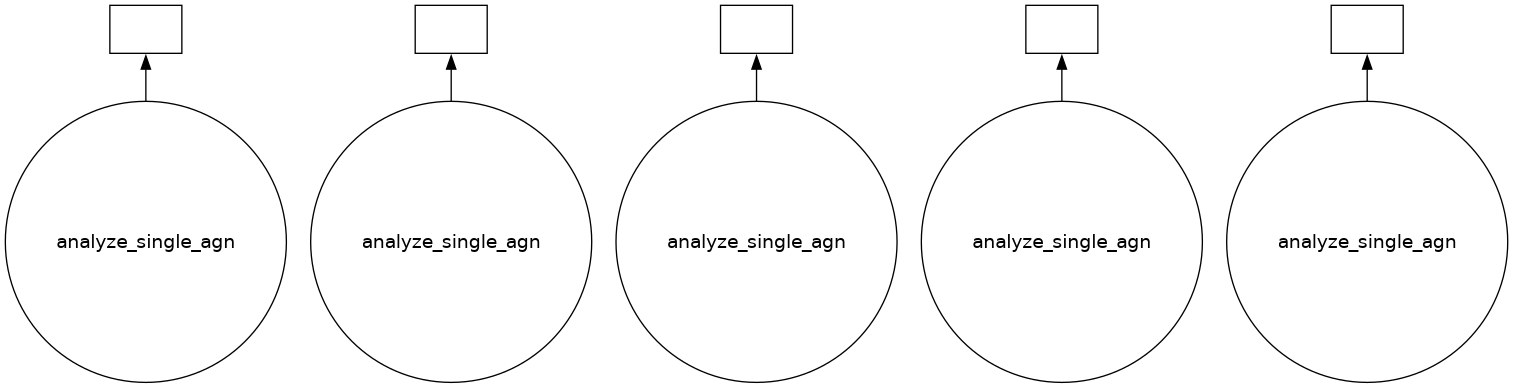

In [13]:
# Visualize the task graph - shows how tasks will be executed in parallel
import dask
dask.visualize(delayed_results, filename="dask-angst.png", engine="graphviz")

In [14]:
# Compute all tasks in parallel
results = compute(*delayed_results)
print(f"Computed {len(results)} results")

/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:337: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:337: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/s

Computed 5 results


In [49]:
# Concatenate all result DataFrames and join as nested column
all_samples_df = pd.concat(results, ignore_index=True)
print(f"Combined samples shape: {all_samples_df.shape}")
all_samples_df.head(2)

Combined samples shape: (1000, 5)


,id,ortho_amps,pred,rho,sin_cos_amps
0,0,"[-11.954820939723252, -8.952806256486788, -1.429144998695486, -22.36384590242165, -3.052278186955507, -0.6643267307757096, 7.5615632624141345, 17.01350730733521, 8.009708661044959, -19.63707540907348]","[-2.7287465055814373, -2.726884403398376, -2.725009994936223, -2.723123308071964, -2.7212243708888044, -2.719313211675763, -2.717389858927253, -2.7154543413426566, -2.7135066878259004, -2.7115469274850286, -2.7095750896317616, -2.707591203781061, -2.7055952996506845, -2.703587407160738, -2.7015675564332278, -2.6995357777915974, -2.6974921017602727, -2.695436559064198, -2.6933691806283577, -2.691289997577318, -2.6891990412347377, -2.687096343122892, -2.684981934962185, -2.6828558486706635, -2.6807181163635168, -2.6785687703525842, -2.6764078431458516, -2.6742353674469386, -2.6720513761546014, -2.6698559023622046, -2.6676489793572067, -2.6654306406206407, -2.6632009198265854, -2.660959850841631, -2.658707467724343, -2.656443804724733, -2.654168896283702, -2.6518827770324997, -2.6495854817921756, -2.647277045573014, -2.644957503573986, -2.642626891182174, -2.6402852439722153, -2.6379325977057184, -2.6355689883306996, -2.6331944519809927, -2.6308090249756715, -2.6284127438184575, -2.6260056451971354, -2.6235877659829505, -2.6211591432300083, -2.618719814174677, -2.6162698162349756, -2.6138091870099642, -2.611337964279128, -2.6088561860017574, -2.6063638903163255, -2.603861115539859, -2.601347900167314, -2.5988242828709316, -2.596290302499606, -2.5937459980782402, -2.5911914088070978, -2.588626574061156, -2.5860515333894485, -2.5834663265144133, -2.5808709933312213, -2.57826557390712, -2.5756501084807604, -2.5730246374615255, -2.570389201428853, -2.5677438411315547, -2.565088597487132, -2.5624235115810903, -2.559748624666244, -2.5570639781620246, -2.554369613653783, -2.5516655728920776, -2.5489518977919836, -2.546228630432369, -2.5434958130551886, -2.540753488064764, -2.5380016980270668, -2.535240485668989, -2.5324698938776202, -2.52968996569951, -2.5269007443399425, -2.5241022731621867, -2.52129459568676, -2.518477755590688, -2.515651796706745, -2.512816763022707, -2.5099726986805955, -2.507119647975919, -2.504257655356907, -2.501386765423744, -2.4985070229278037, -2.4956184727708717, -2.4927211600043675, -2.48981512982857, ...]","[1.9952659527486196, 1.1175470950673012, 0.6577438881893864, 1.3698885410146837, 0.7239706513568528]","[-1.406462035317292, -1.0095453763021953, -0.22277614500758575, 0.7602151215835299, -0.8501780705378942, 0.13088352058131625, 0.31363231379142054, -0.779817079451935, 0.8899221931890577, 0.03417454803382575]"
1,0,"[-9.248089290993871, -10.319756201884207, -0.6160018223060904, -23.883202948721113, -0.89553989389623, -0.7372383925622505, 8.613357139614706, 16.349315921397533, 5.797892880325344, -17.086223643032504]","[-2.363514301856764, -2.3623633525247034, -2.361203068331409, -2.3600334711698783, -2.3588545830990504, -2.3576664263434637, -2.3564690232929046, -2.3552623965020505, -2.354046568690114, -2.3528215627404836, -2.3515874017003555, -2.3503441087803667, -2.3490917073542215, -2.347830220958317, -2.3465596732913663, -2.345280088214013, -2.343991489748443, -2.342693902078004, -2.3413873495467956, -2.340071856659293, -2.33874744807993, -2.3374141486327042, -2.336071983300766, -2.334720977226012, -2.3333611557086646, -2.3319925442068588, -2.3306151683362204, -2.3292290538694393, -2.3278342267358454, -2.326430713020973, -2.3250185389661264, -2.3235977309679434, -2.322168315577954, -2.320730319502132, -2.3192837696004447, -2.3178286928864096, -2.3163651165266295, -2.314893067840338, -2.3134125742989378, -2.31192366352553, -2.310426363294453, -2.308920701530801, -2.3074067063099584, -2.3058844058571086, -2.3043538285467635, -2.3028150029022694, -2.3012679575953197, -2.299712721445464, -2.298149323419613, -2.296577792631538, -2.2949981583413637, -2.2934104499550725, -2.2918146970239874, -2.290210929244262, -2.288599176456368, -2.2869794686445726, -2.285351835936416

In [50]:
# Use join_nested to add the posterior samples as a nested column
final_df = dset.df.join_nested(all_samples_df, name="posterior", on="id")
final_df.head(2)

id          ra        dec  \
0   0  234.692012  45.102399   
1   1  145.523735  -66.04436   

                                                  lc  \
0  [{mjd: 1.400884, mag: 16.925767, mag_error: 1....   
1  [{mjd: 0.44321, mag: 16.866241, mag_error: 1.4...   

                                    input_parameters  \
0  [{DRW_amplitude: 2.693091, DRW_timescale: 170....   
1  [{DRW_amplitude: 0.673117, DRW_timescale: 191....   

                                           posterior  
0  [{ortho_amps: array([-11.95482094,  -8.9528062...  
1  [{ortho_amps: array([ 2.8217023 ,  4.11131444,...

In [23]:
# Access samples for a specific AGN - they are now stored as a nested dataframe
agn_idx = 0
posterior = final_df.iloc[agn_idx]["posterior"]
posterior.head()

,ortho_amps,pred,rho,sin_cos_amps
0,"[-11.954820939723252, -8.952806256486788, -1.4...","[-2.7287465055814373, -2.726884403398376, -2.7...","[1.9952659527486196, 1.1175470950673012, 0.657...","[-1.406462035317292, -1.0095453763021953, -0.2..."
1,"[-9.248089290993871, -10.319756201884207, -0.6...","[-2.363514301856764, -2.3623633525247034, -2.3...","[2.097229080350691, 0.7056312657898614, 0.9091...","[-1.4451064016553983, -0.7916331942949157, -0...."
2,"[-11.954868109526375, -8.54343713994688, -0.66...","[-2.6870429399247158, -2.685303111257911, -2.6...","[1.9774866362845296, 1.1612849053443126, 0.723...","[-1.40224630960746, -1.0339260919901712, -0.24..."
3,"[-10.588063853214654, -7.9740635067704755, -0....","[-2.7027694858339917, -2.7011242882635775, -2....","[2.0680316022908345, 1.2135145204390783, 0.721...","[-1.428009126150346, -1.058476956157041, -0.20..."
4,"[-10.0338957507668, -10.149189574013546, -0.85...","[-2.6932516283528023, -2.6916438975379307, -2....","[2.2570761284601693, 0.747893115958406, 0.7666...","[-1.5022518583310576, -0.7881818314497874, -0...."


In [43]:
np.stack(final_df.iloc[[agn_idx]]["posterior.ortho_amps"].to_numpy()).shape

(200, 10)

In [46]:
# Save the results with posterior samples as a nested column
output_file = Path.cwd() / "free-spec-analyses-w-coefficients.pq"
final_df.to_parquet(output_file)
print(f"Results saved to {output_file}")

# Verify we can read it back
reloaded_df = npd.read_parquet(output_file)
print("Reloaded dataframe:")
reloaded_df.head(1)

Results saved to /home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/docs/free-spec-analyses-w-coefficients.pq
Reloaded dataframe:


id          ra        dec  \
0   0  234.692012  45.102399   

                                                  lc  \
0  [{mjd: 1.400884, mag: 16.925767, mag_error: 1....   

                                    input_parameters  \
0  [{DRW_amplitude: 2.693091, DRW_timescale: 170....   

                                           posterior  
0  [{ortho_amps: array([-11.95482094,  -8.9528062...

## Using with LSDB Catalogs

When working with LSDB catalogs (loaded via `lsdb.read_hats()`), the data is already partitioned by HEALPix. You have two options:

### Option 1: Use `@delayed` as shown above
This works identically - just iterate over rows in the catalog's computed dataframe.

### Option 2: Use `map_partitions` for partition-level parallelism
For very large catalogs, you can process all AGN within each partition together:

```python
import lsdb

catalog = lsdb.read_hats("/path/to/catalog")

def analyze_partition(partition_df, nfreq=5, num_samples=200, num_warmup=100):
    """Process all AGN in a single partition."""
    if len(partition_df) == 0:
        return partition_df
    
    all_samples = []
    for idx, row in partition_df.iterrows():
        agn_id = row["id"]
        single_row_df = partition_df.loc[[idx]]
        
        # Create DataSet and run analysis (same as analyze_single_agn)
        dset = dataset.DataSet(single_row_df)
        freespec = analysis.SingleAGNFreeSpectrum(...)
        # ... run MCMC and collect samples ...
        all_samples.append(sample_df)
    
    # Join all samples back to the partition
    combined = pd.concat(all_samples, ignore_index=True)
    return partition_df.join_nested(combined, name="posterior", on="id")

# Apply to all partitions in parallel
result = catalog.map_partitions(analyze_partition, nfreq=5, num_samples=200)
result.compute()  # or result.write_catalog("/output/path")
```

**When to use each approach:**
- **`@delayed`**: Best for small-to-medium datasets where you want fine-grained task parallelism
- **`map_partitions`**: Best for large HATS catalogs where partition-level parallelism is more efficient

Both approaches store results using `join_nested` for compatibility with the nested-pandas data model.